# 04c – Exploration de la densité des professionnels de santé (Ameli 2024)
 

**Source** : [Assurance Maladie – Densité des professionnels de santé libéraux](https://www.assurance-maladie.ameli.fr/etudes-et-donnees/densite-professionnels-sante-liberaux-departement)


**Limites des données Ameli** (d'après l'onglet « Lisez moi »)
- Seuls les professionnels libéraux actifs au 31 décembre 2024, ayant eu une activité remboursée par l'Assurance Maladie, sont comptés. Les médecins salariés (hôpitaux, centres de santé) sont exclus : les départements avec beaucoup d'hôpitaux (ex. Paris) peuvent paraître moins bien dotés en médecins qu'en réalité.
- La densité est calculée sur la **population Insee** (population résidente) : les touristes  ne sont pas comptés. Dans les départements touristiques (montagne, littoral), la densité de médecins est donc probablement surestimée pour certains départements et certains saisons (montagne en hiver, plage en été).
- La densité des pédiatres est calculée sur la population de 0 à 19 ans : elle n'est pas directement comparable à celle des autres médecins mais possible entre départements.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

**Plan** : Importation → Contrôle → Nettoyage → Inspection → Visualisation

### Importation des données

In [2]:
# Charger le fichier et afficher le nom des onglets
fichier_ameli = pd.ExcelFile('../data/raw/Socio Eco/ameli_densite_2024.xls')
print(fichier_ameli.sheet_names)

['Lisez moi', 'Nomenclature des PS', 'Spécialistes', 'Généralistes et MEP', 'Dentistes et ODF', 'Sages-femmes', 'Auxiliaires médicaux', 'Laboratoires', 'Psychologues']


Le fichier a 9 onglets. Je garde seulement ceux utiles pour les maladies respiratoires :
- les généralistes
-  les spécialistes (pneumologues, pédiatres) 
- et les kinés (kinésithérapie respiratoire).

Sélection des généralistes

In [3]:
# Charger l'onglet des généralistes
ameli_gen = pd.read_excel(fichier_ameli, sheet_name='Généralistes et MEP')

print(ameli_gen.shape)
ameli_gen.head()

(6968, 5)


,Généralistes et compétence MEP,DEPARTEMENT,EFFECTIF,POPULATION FRANCAISE,DENSITE /100 000 hab.
0,01- Médecine générale,01- Ain,368,688626,53.439748
1,01- Médecine générale,02- Aisne,311,518817,59.944065
2,01- Médecine générale,03- Allier,221,332599,66.446381
3,01- Médecine générale,04- Alpes-Hte-Provence,152,169806,89.513916
4,01- Médecine générale,05- Hautes-Alpes,178,142006,125.346816


### Contrôle des données

In [4]:
# Catégories de médecins dans l'onglet (et nombre de lignes pour chacune)
print(ameli_gen.iloc[:, 0].value_counts())
print("---------------------------------------------------------------------")
# Nombre de départements différents
print(ameli_gen['DEPARTEMENT'].nunique())
print("---------------------------------------------------------------------")
# Afficher les noms des lignes de total (ce ne sont pas des départements)
print(ameli_gen[ameli_gen['DEPARTEMENT'].str.contains('TOTAL', na=False)]['DEPARTEMENT'].unique())

Généralistes et compétence MEP
01- Médecine générale                          104
01- M.E.P.                                     104
01- OMNIPRATICIENS                             104
01- Acupuncture                                104
02- Homéopathie                                104
                                              ... 
89- Orthopédie dento-faciale exclusive         104
90- Sexologie                                  104
91- Echotomographie et Médecine Générale       104
92- Médecine d'urgence et Médecine Générale    104
93- SOS Médecins                               104
Name: count, Length: 67, dtype: int64
---------------------------------------------------------------------
104
---------------------------------------------------------------------
<ArrowStringArray>
['TOTAL FRANCE METROPOLITAINE', 'TOTAL OUTRE-MER', 'TOTAL France ENTIERE']
Length: 3, dtype: str


In [5]:
# Nombre de cases vides dans chaque colonne
print(ameli_gen.isna().sum())

ameli_gen.tail()

Généralistes et compétence MEP    0
DEPARTEMENT                       0
EFFECTIF                          0
POPULATION FRANCAISE              0
DENSITE /100 000 hab.             0
dtype: int64


,Généralistes et compétence MEP,DEPARTEMENT,EFFECTIF,POPULATION FRANCAISE,DENSITE /100 000 hab.
6963,93- SOS Médecins,973- Guyane,0,292354,0.000000
6964,93- SOS Médecins,974- Réunion,0,896175,0.000000
6965,93- SOS Médecins,976- Mayotte,0,329282,0.000000
6966,93- SOS Médecins,TOTAL OUTRE-MER,1,2253657,0.044372
6967,93- SOS Médecins,TOTAL France ENTIERE,431,68605616,0.628228


L'onglet contient 67 catégories de médecins, chacune avec 104 lignes : 101 départements et 3 lignes de total (France métropolitaine, Outre-mer, France entière). Aucunes donnée n'est manquante.
Je garde uniquement la catégorie « Médecine générale » et les lignes de total sont gardées comme référence.

### Nettoyage des données

In [6]:
# Garder seulement les médecins généralistes
gen = ameli_gen[ameli_gen.iloc[:, 0] == '01- Médecine générale'].copy()

# Mettre de côté les lignes de total (références nationales)
references_gen = gen[gen['DEPARTEMENT'].str.contains('TOTAL', na=False)]

# Retirer les lignes de total de la liste de médecin généraliste
gen = gen[~gen['DEPARTEMENT'].str.contains('TOTAL', na=False)]

# Séparer le code et le nom du département car certains noms de départements sont raccourcis (différent selon les fichiers a,b ou c)
gen[['code_dep', 'nom_dep']] = gen['DEPARTEMENT'].str.split('- ', n=1, expand=True)

# Garder les colonnes utiles et les renommer
gen = gen[['code_dep', 'nom_dep', gen.columns[2], gen.columns[3], gen.columns[4]]]
gen.columns = ['code_dep', 'nom_dep', 'nb_generalistes', 'population', 'densite_generalistes']

# Repérer les DROM et renuméroter (code 97)
gen['est_drom'] = gen['code_dep'].str.startswith('97')
gen = gen.reset_index(drop=True)

print(gen.shape)                        
print(gen['est_drom'].value_counts())   
gen.head()

(101, 6)
est_drom
False    96
True      5
Name: count, dtype: int64


,code_dep,nom_dep,nb_generalistes,population,densite_generalistes,est_drom
0,01,Ain,368,688626,53.439748,False
1,02,Aisne,311,518817,59.944065,False
2,03,Allier,221,332599,66.446381,False
3,04,Alpes-Hte-Provence,152,169806,89.513916,False
4,05,Hautes-Alpes,178,142006,125.346816,False


In [7]:
# Contrôle approfondi des codes de départements
codes_valides = [f"{i:02d}" for i in range(1, 96) if i != 20] + ['2A', '2B', '971', '972', '973', '974', '976']

# Affiche les lignes dont le code n'est pas un vrai département(~)
print(gen[~gen['code_dep'].isin(codes_valides)])

Empty DataFrame
Columns: [code_dep, nom_dep, nb_generalistes, population, densite_generalistes, est_drom]
Index: []


Après nettoyage: 101 départements (96 en métropole et 5 DROM). Comme certains noms sont abrégés dans ce fichier (ex: « Alpes-Hte-Provence »), la fusion avec les fichiers INSEE se fera en utilisant le code départementale comme référence.

### Inspection

In [8]:
# Types des colonnes
print(gen.dtypes)
print("---------------------------------------------------------------------")

# Cases vides
print(gen.isna().sum())
print("---------------------------------------------------------------------")

# Contrôle de cohérence : recalculer la densité et comparer avec celle d'Ameli
densite_calculee = gen['nb_generalistes'] / gen['population'] * 100000
ecart = (densite_calculee - gen['densite_generalistes']).abs()
print("Écart maximum entre la densité calculée et celle d'Ameli :", ecart.max())
print("---------------------------------------------------------------------")

# Statistiques descriptives
print(gen[['nb_generalistes', 'population', 'densite_generalistes']].describe())
print("---------------------------------------------------------------------")
# Lien entre nombre de généralistes et population
print("Corrélation :", gen['nb_generalistes'].corr(gen['population']))

code_dep                    str
nom_dep                     str
nb_generalistes           int64
population                int64
densite_generalistes    float64
est_drom                   bool
dtype: object
---------------------------------------------------------------------
code_dep                0
nom_dep                 0
nb_generalistes         0
population              0
densite_generalistes    0
est_drom                0
dtype: int64
---------------------------------------------------------------------
Écart maximum entre la densité calculée et celle d'Ameli : 0.0
---------------------------------------------------------------------
       nb_generalistes    population  densite_generalistes
count       101.000000  1.010000e+02            101.000000
mean        512.623762  6.792635e+05             73.376661
std         447.060440  5.245078e+05             18.086279
min          29.000000  7.645200e+04              8.807041
25%         186.000000  2.958300e+05             59.26475

Le type chaque variables est correct et aucune valeur n'est manquante. La densité calculée (nombre de généralistes/population × 100 000) est identique à celle d'Ameli.
La densité de généralistes varie de 8,8 à 125,3 pour 100 000 habitants (médiane : 75): inégalités d'accès aux soins entre départements.
Le nombre de généralistes est lié à la population du département (corrélation de 0,94). La variable densité sera utilisée pour comparer l'accès aux soins.

### Visualisation

In [9]:
# Les 10 départements avec le moins de généralistes (déserts médicaux)
print(gen.nsmallest(10, 'densite_generalistes')[['nom_dep', 'densite_generalistes']])
print("---------------------------------------------------------------------")

# Les 10 départements avec le plus de généralistes
print(gen.nlargest(10, 'densite_generalistes')[['nom_dep', 'densite_generalistes']])

            nom_dep  densite_generalistes
100         Mayotte              8.807041
98           Guyane             32.836903
93   Seine-St-Denis             44.103662
17             Cher             45.972349
77   Seine-et-Marne             46.430997
28     Eure-et-Loir             47.789670
91          Essonne             48.454553
89            Yonne             50.433212
95       Val-d'Oise             50.870270
27             Eure             53.327397
---------------------------------------------------------------------
                 nom_dep  densite_generalistes
4           Hautes-Alpes            125.346816
73                Savoie            106.364433
64  Pyrénées-Atlantiques            103.856860
5        Alpes-Maritimes            101.685915
33               Gironde            100.718353
99               Réunion            100.538399
12      Bouches-du-Rhône             99.319451
67              Bas-Rhin             98.915946
29             Finistère             97.51793

Densité France métropolitaine : 75.5


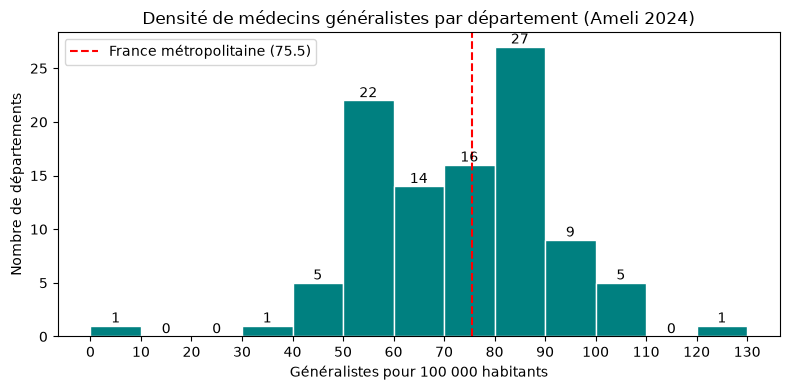

Le nombre de départements qui ont une densité de médecins généralistes en dessous de la référence France métropolitaine est de: 51


In [10]:
# Densité de référence en France métropolitaine (ligne de total mise de côté au nettoyage)
ref_metro = references_gen[references_gen['DEPARTEMENT'] == 'TOTAL FRANCE METROPOLITAINE'].iloc[0, 4]
print("Densité France métropolitaine :", round(ref_metro, 1))

# Histogramme (tranches de 10)
fig, ax = plt.subplots(figsize=(8, 4))
tranches = range(0, 131, 10)
barres = ax.hist(gen['densite_generalistes'], bins=tranches, color='teal', edgecolor='white')

# Nombre de départements au-dessus de chaque barre
ax.bar_label(barres[2])

# Ligne de référence France métropolitaine
ax.axvline(ref_metro, color='red', linestyle='--', label=f'France métropolitaine ({ref_metro:.1f})')

# Titres et légende
ax.set_xticks(tranches)
ax.set_xlabel('Généralistes pour 100 000 habitants')
ax.set_ylabel('Nombre de départements')
ax.set_title('Densité de médecins généralistes par département (Ameli 2024)')
ax.legend()
plt.tight_layout()
plt.show()

# Nombre de départements en dessous de la référence France métropolitaine
print(("Le nombre de départements qui ont une densité de médecins généralistes en dessous de la référence France métropolitaine est de:"),(gen['densite_generalistes'] < ref_metro).sum())

### Conclusion – Médecins généralistes

- **Fortes inégalités** : la densité varie de 8,8 (Mayotte) à 125,3 (Hautes-Alpes) généralistes pour 100 000 habitants, pour une référence de 75,5 en France métropolitaine. 51 départements sur 101 sont en dessous de cette référence.


**Hypothèse à tester** : une faible densité de généralistes pourrait être associée à davantage de passages aux urgences pour pathologies respiratoires.
